In [14]:
import ltn
import torch
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Nodes information
raw_nodes = {
    "Hannover": (9.80, 52.39),
    "Frankfurt": (8.66, 50.14),
    "Hamburg": (10.08, 53.55),
    "Norden": (7.21, 53.60),
    "Bremen": (8.80, 53.08),
    "Berlin": (13.48, 52.52),
    "Muenchen": (11.55, 48.15),
    "Ulm": (9.99, 48.40),
    "Nuernberg": (11.08, 49.45),
    "Stuttgart": (9.12, 48.73),
    "Karlsruhe": (8.41, 49.01),
    "Mannheim": (8.49, 49.49),
    "Essen": (7.00, 51.44),
    "Dortmund": (7.48, 51.51),
    "Duesseldorf": (6.78, 51.22),
    "Koeln": (7.01, 50.92),
    "Leipzig": (12.38, 51.34)
}
# Convert raw_nodes to LTN constants
embedding_size = 2
nodes = {k: ltn.Constant(torch.rand((embedding_size,)), trainable=True) for k, v in raw_nodes.items()}
# nodes = {k: ltn.Constant(torch.tensor(v, device=device)) for k, v in raw_nodes.items()}


# Links information
raw_links = {
    "L1": ("Berlin", "Hamburg"),
    "L2": ("Berlin", "Hannover"),
    "L3": ("Berlin", "Leipzig"),
    "L4": ("Bremen", "Hamburg"),
    "L5": ("Bremen", "Hannover"),
    "L6": ("Bremen", "Norden"),
    "L7": ("Dortmund", "Essen"),
    "L8": ("Dortmund", "Hannover"),
    "L9": ("Dortmund", "Koeln"),
    "L10": ("Dortmund", "Norden"),
    "L11": ("Duesseldorf", "Essen"),
    "L12": ("Duesseldorf", "Koeln"),
    "L13": ("Frankfurt", "Hannover"),
    "L14": ("Frankfurt", "Koeln"),
    "L15": ("Frankfurt", "Leipzig"),
    "L16": ("Frankfurt", "Mannheim"),
    "L17": ("Frankfurt", "Nuernberg"),
    "L18": ("Hamburg", "Hannover"),
    "L19": ("Hannover", "Leipzig"),
    "L20": ("Karlsruhe", "Mannheim"),
    "L21": ("Karlsruhe", "Stuttgart"),
    "L22": ("Leipzig", "Nuernberg"),
    "L23": ("Muenchen", "Nuernberg"),
    "L24": ("Muenchen", "Ulm"),
    "L25": ("Nuernberg", "Stuttgart"),
    "L26": ("Stuttgart", "Ulm")
}
# define the link relation
links = list(raw_links.values())

In [ ]:
def parse_demands(filepath):
    """
    Parse demands data from the text file and extract source, target, and value information
    
    Args:
        filepath (str): Path to the demand matrix file
        
    Returns:
        tuple: Three lists containing sources, targets, and values
    """
    sources = []
    targets = []
    values = []
    
    with open(filepath, 'r') as f:
        lines = f.readlines()
        demands_section = False
        
        for line in lines:
            # Start reading after DEMANDS section
            if line.strip() == "DEMANDS (":
                demands_section = True
                continue
            # Stop reading at the end of DEMANDS section    
            if line.strip() == ")":
                demands_section = False
                continue
                
            if demands_section and line.strip():
                # Parse each demand line
                # Example: Bremen_Nuernberg ( Bremen Nuernberg ) 1 0.011252 UNLIMITED
                parts = line.strip().split()
                if len(parts) >= 5:  # Ensure line has all required parts
                    source = parts[2]  # Bremen
                    target = parts[3]  # Nuernberg 
                    value = float(parts[6])  # 0.011252
                    
                    sources.append(source)
                    targets.append(target)
                    values.append(value)
    
    return sources, targets, values


filepath = "./P3_knowlegeembed/directed-nobel-germany-DFN-aggregated-5min-over-1day-native/demandMatrix-germany17-DFN-5min-20050215-0000.txt"
sources, targets, values = parse_demands(filepath)

# Combine into list of (source, target, value) tuples
demands = list(zip(sources, targets, values))

# Example to verify the data:
print(f"Total number of demands: {len(demands)}")
print("\nFirst 5 demands:")
for source, target, value in demands[:5]:
    print(f"{source} -> {target}: {value:.6f}")


Total number of demands: 251

First 5 demands:
Bremen -> Nuernberg: 0.011252
Bremen -> Hamburg: 0.090648
Berlin -> Dortmund: 0.525671
Stuttgart -> Nuernberg: 0.351524
Mannheim -> Duesseldorf: 0.000004


In [16]:
# the link down event only effects the links that are directly connected to the link that is down
# 1. Find the links that are directly connected to the link that is down
# 2. Find the demands that are affected by the link down event

# Find the links that are directly connected to the link that is down
down_link = ("Berlin", "Hamburg")
affected_links = [l for l in links if l[0] in down_link or l[1] in down_link]
print("\nLinks directly connected to the down link:")
for l in affected_links:
    print(f"{l[0]} -> {l[1]}")

# So there are 4 links directly connected to the down link, which are: L1, L2, L18, L4 (assign to the affected_links)
# 3 nodes are directly connected to the down link, which are: Berlin, Hamburg, Hannover, Bremen, and Leipzig (assign to the affected_nodes)


Links directly connected to the down link:
Berlin -> Hamburg
Berlin -> Hannover
Berlin -> Leipzig
Bremen -> Hamburg
Hamburg -> Hannover


## $KT_{0}$ -- baseline knowledge topology

Two-level knowledge topology forged from one 5-min demand matrix (uses `raw_nodes`, `raw_links`, `demands` from the cells above):

- **Node** (17): geography = (lon, lat); demand level = act0(v) = origin + destination + transit volume.
- **Directed link** (52 = 26 x 2): geography = w_g (Euclidean distance on (lon, lat), symmetric); demand level = w_0(s->t) (link load, directional).

Routing: each of the 251 directed demands follows the shortest path with edge weight w_g (deterministic -- no tied shortest paths on this topology). Transit volume of v = total demand whose route passes through v as an intermediate hop. R4 (anti-reflexivity) holds by construction: no self-links, and the data contains no self-demands.

In [17]:
# ---- KT0: compute w_g (geographic link weight), routes, w_0 (directed link load), act0 (node activity) ----
import math
import networkx as nx

def geo_dist(a, b):
    (x1, y1), (x2, y2) = raw_nodes[a], raw_nodes[b]
    return math.hypot(x2 - x1, y2 - y1)

# Geography level: undirected graph weighted by geographic distance (also the routing metric)
G0 = nx.Graph()
for (a, b) in links:
    G0.add_edge(a, b, w_g=geo_dist(a, b))

# Route all demands by geographic shortest path (verified: no tied shortest paths -> deterministic)
routes = {(s, t): nx.shortest_path(G0, s, t, weight="w_g") for (s, t, v) in demands}

# w_g: symmetric geographic weight per directed link
w_g = {}
for (a, b) in links:
    w_g[(a, b)] = w_g[(b, a)] = geo_dist(a, b)

# w_0: directed link load = sum of demand values routed over that directed link
w0 = {d: 0.0 for pair in links for d in (pair, pair[::-1])}
# act0 components: origin + destination + transit
act_origin  = {n: 0.0 for n in raw_nodes}
act_dest    = {n: 0.0 for n in raw_nodes}
act_transit = {n: 0.0 for n in raw_nodes}

for (s, t, v) in demands:
    path = routes[(s, t)]
    for (a, b) in zip(path, path[1:]):
        w0[(a, b)] += v
    act_origin[s] += v
    act_dest[t] += v
    for n in path[1:-1]:          # intermediate hops only
        act_transit[n] += v

act0 = {n: act_origin[n] + act_dest[n] + act_transit[n] for n in raw_nodes}

# Normalized w_0 (kept separately; raw values shown on the plot)
w0_max = max(w0.values())
w0_norm = {k: v / w0_max for k, v in w0.items()}

print(f"demands routed: {len(routes)} | multi-hop: {sum(1 for p in routes.values() if len(p) > 2)}")
print(f"total demand: {sum(v for _, _, v in demands):.2f}")
print("top-5 act0:", [(n, round(a, 1)) for n, a in sorted(act0.items(), key=lambda x: -x[1])[:5]])
print(f"w_0 asymmetry example: Berlin->Hamburg {w0[('Berlin','Hamburg')]:.2f} vs Hamburg->Berlin {w0[('Hamburg','Berlin')]:.2f}")


demands routed: 251 | multi-hop: 199
total demand: 3512.47
top-5 act0: [('Frankfurt', 2909.8), ('Leipzig', 1299.4), ('Hannover', 941.6), ('Koeln', 835.3), ('Nuernberg', 652.8)]
w_0 asymmetry example: Berlin->Hamburg 2.84 vs Hamburg->Berlin 0.38


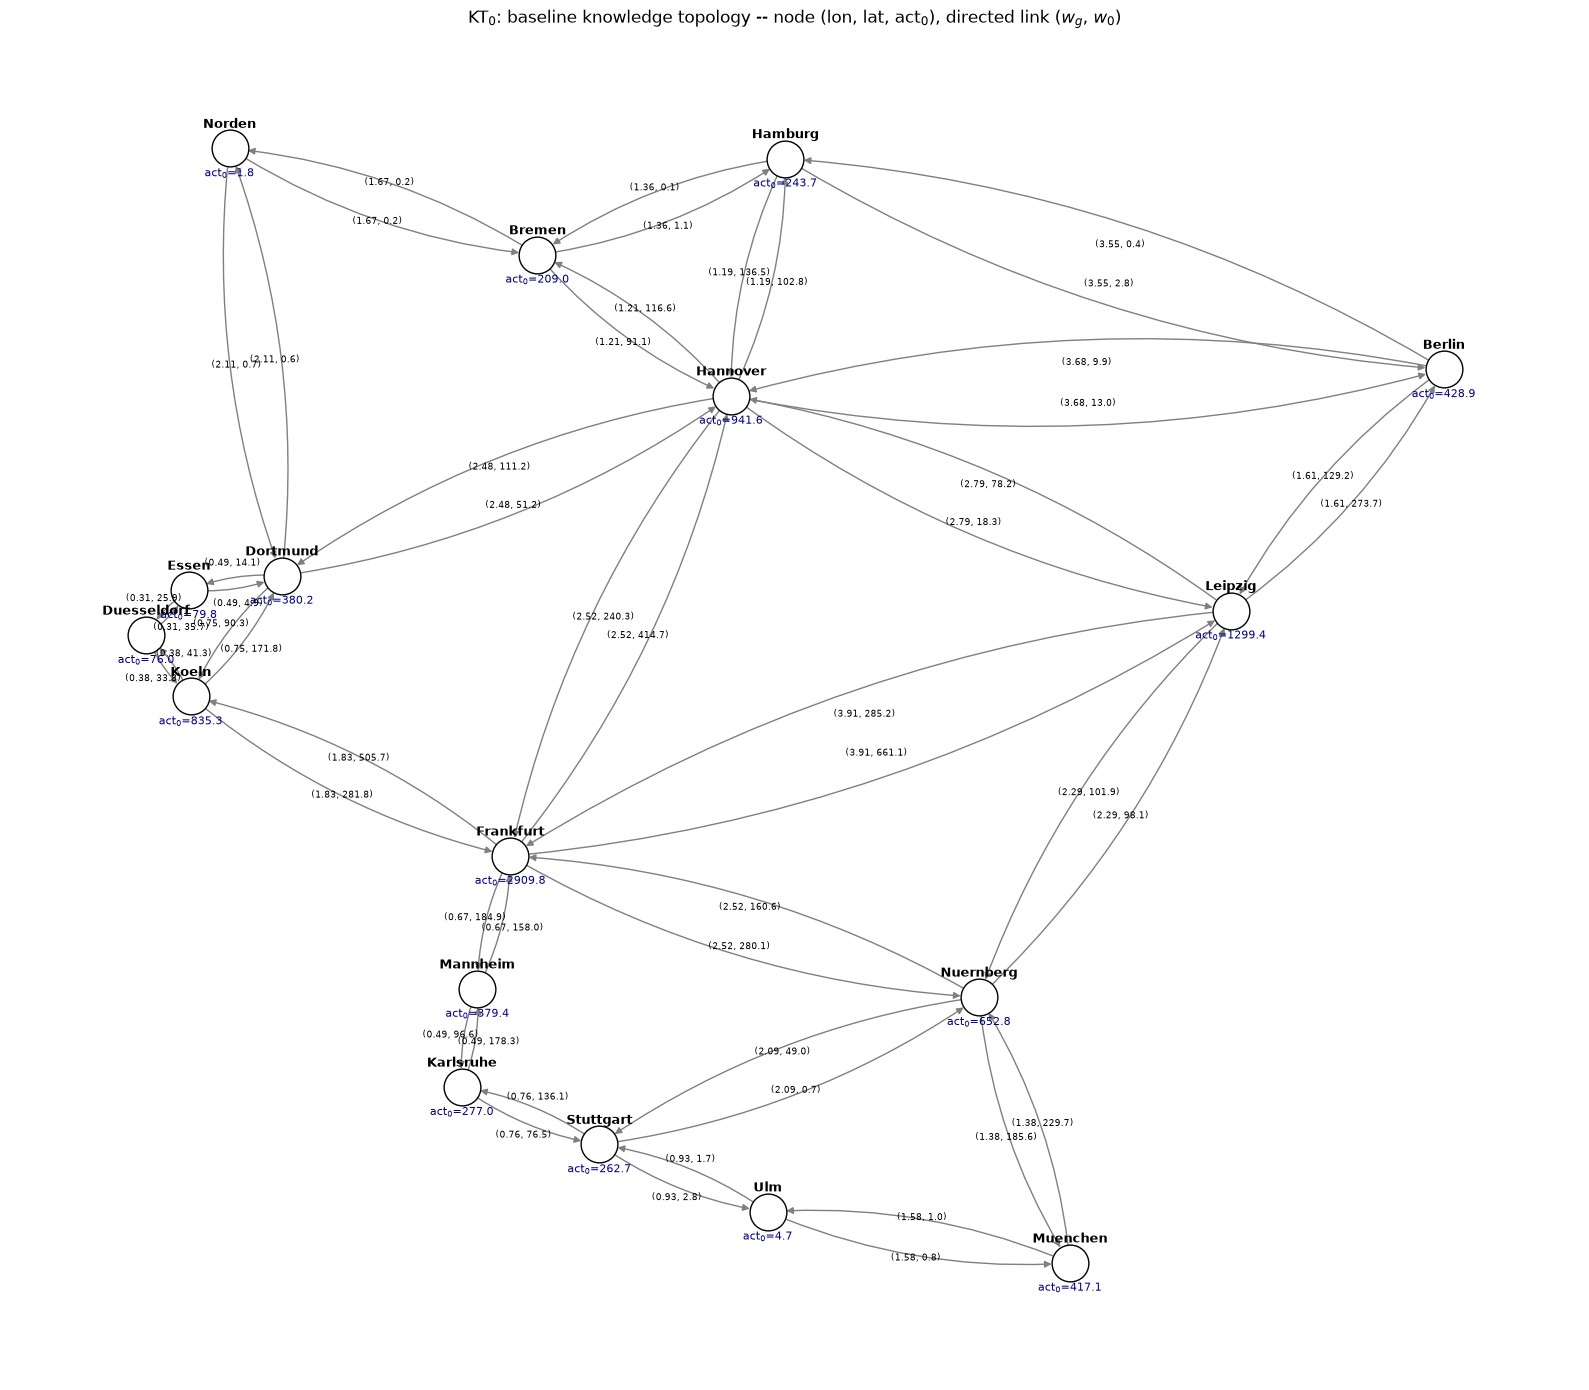

In [18]:
# ---- Plot KT0: bidirected graph, node (name, act0) at (lon, lat), directed edge labels (w_g, w_0) ----
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 14))
pos = raw_nodes

KTG = nx.DiGraph()
KTG.add_nodes_from(raw_nodes)
for (a, b) in links:
    KTG.add_edge(a, b)
    KTG.add_edge(b, a)

nx.draw_networkx_nodes(KTG, pos, node_size=700, node_color="white", edgecolors="black", ax=ax)
nx.draw_networkx_edges(KTG, pos, arrows=True, arrowsize=10, edge_color="grey",
                       connectionstyle="arc3,rad=0.12", ax=ax, node_size=700)

# node labels: city name above, act0 below
for n, (x, y) in pos.items():
    ax.text(x, y + 0.10, n, ha="center", fontsize=9, fontweight="bold")
    ax.text(x, y - 0.14, f"act$_0$={act0[n]:.1f}", ha="center", fontsize=8, color="darkblue")

# edge labels: one per direction, offset to the arc side of that direction
for (a, b) in KTG.edges():
    (x1, y1), (x2, y2) = pos[a], pos[b]
    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    dx, dy = x2 - x1, y2 - y1
    L = math.hypot(dx, dy)
    px, py = -dy / L, dx / L        # perpendicular, arc side for rad>0
    off = 0.10
    ax.text(mx + px * off, my + py * off, f"({w_g[(a, b)]:.2f}, {w0[(a, b)]:.1f})",
            ha="center", va="center", fontsize=6.5, color="black")

ax.set_title("KT$_0$: baseline knowledge topology -- node (lon, lat, act$_0$), directed link ($w_g$, $w_0$)")
ax.set_axis_off()
plt.tight_layout()
plt.show()


## KT1 -- ground-truth knowledge topology after the event (two-tier suppression)

Event: down_link = (Berlin, Hamburg). Geography level is invariant (nodes keep (lon, lat), links keep w_g -- R1 stays exact). The event lives entirely at the demand level:

- **Tier 1** (route crosses the down link L1): demand fully suppressed, F_d = 0. Hence w_1(L1) = 0 exactly.
- **Tier 2** (route crosses an affected link L2/L3/L4/L18 from rules R2/R3, but not L1): F_d = 1 - beta (default beta = 0.5).
- Otherwise F_d = 1.

D' = F (elementwise) D, routes unchanged; act1 and w_1 are computed from D' with the identical KT0 pipeline. Ground-truth ratios (evaluation targets, data-measured -- not rule-assigned): DF1(v) = act1(v)/act0(v), rho(l) = w_1(l)/w_0(l).

In [19]:
# ---- KT1: two-tier suppression -> D', then act1 / w_1 with the same pipeline as KT0 ----
down_link = ("Berlin", "Hamburg")
beta = 0.5

down_set = frozenset(down_link)
# R2/R3 (1-hop): links sharing an endpoint with the down link -> L2, L3, L4, L18
affected_link_set = {frozenset(l) for l in links
                     if l[0] in down_link or l[1] in down_link} - {down_set}

def demand_factor(path, beta):
    """Two-tier suppression factor F_d of one demand, decided by its (unchanged) route."""
    edges = {frozenset(e) for e in zip(path, path[1:])}
    if down_set in edges:                 # tier 1: route crosses the down link
        return 0.0
    if edges & affected_link_set:         # tier 2: route crosses an affected link
        return 1.0 - beta
    return 1.0

def compute_kt(demand_list):
    """Same pipeline as KT0: directed link loads w and node activity act (origin+dest+transit)."""
    w = {d: 0.0 for pair in links for d in (pair, pair[::-1])}
    act = {n: 0.0 for n in raw_nodes}
    for (s, t, v) in demand_list:
        p = routes[(s, t)]
        for (a, b) in zip(p, p[1:]):
            w[(a, b)] += v
        act[s] += v
        act[t] += v
        for n in p[1:-1]:
            act[n] += v
    return w, act

# F, D' and KT1 quantities
F = {(s, t): demand_factor(routes[(s, t)], beta) for (s, t, v) in demands}
demands_event = [(s, t, v * F[(s, t)]) for (s, t, v) in demands]
w1, act1 = compute_kt(demands_event)

# Ground-truth ratios (evaluation targets)
DF1 = {n: (act1[n] / act0[n] if act0[n] > 0 else 1.0) for n in raw_nodes}
rho = {l: (w1[l] / w0[l] if w0[l] > 0 else 1.0) for l in w0}

n_t1 = sum(1 for f in F.values() if f == 0.0)
n_t2 = sum(1 for f in F.values() if f == 1.0 - beta)
print(f"tier1 (F=0): {n_t1} demands | tier2 (F={1-beta}): {n_t2} | untouched: {len(F) - n_t1 - n_t2}")
print("\nDF1 (sorted, most affected first):")
for n, d in sorted(DF1.items(), key=lambda x: x[1]):
    print(f"  {n}: {d:.3f}")
print(f"\nrho(down link) = {rho[down_link]:.3f} (exact 0 by construction)")


tier1 (F=0): 2 demands | tier2 (F=0.5): 60 | untouched: 189

DF1 (sorted, most affected first):
  Hamburg: 0.493
  Berlin: 0.496
  Leipzig: 0.840
  Hannover: 0.861
  Dortmund: 0.909
  Nuernberg: 0.918
  Stuttgart: 0.918
  Muenchen: 0.923
  Frankfurt: 0.933
  Norden: 0.951
  Koeln: 0.988
  Bremen: 0.995
  Karlsruhe: 0.996
  Mannheim: 0.997
  Ulm: 0.998
  Essen: 0.999
  Duesseldorf: 1.000

rho(down link) = 0.000 (exact 0 by construction)


In [20]:
# ---- beta sensitivity check over {0.3, 0.5, 0.7} ----
for b in (0.3, 0.5, 0.7):
    Fb = {(s, t): demand_factor(routes[(s, t)], b) for (s, t, v) in demands}
    de = [(s, t, v * Fb[(s, t)]) for (s, t, v) in demands]
    _, a1 = compute_kt(de)
    df = {n: a1[n] / act0[n] for n in raw_nodes}
    top = sorted(df.items(), key=lambda x: x[1])[:5]
    print(f"beta={b}: " + " | ".join(f"{n} {v:.3f}" for n, v in top))


beta=0.3: Hamburg 0.691 | Berlin 0.695 | Leipzig 0.904 | Hannover 0.916 | Dortmund 0.945
beta=0.5: Hamburg 0.493 | Berlin 0.496 | Leipzig 0.840 | Hannover 0.861 | Dortmund 0.909
beta=0.7: Hamburg 0.296 | Berlin 0.298 | Leipzig 0.776 | Hannover 0.805 | Dortmund 0.872


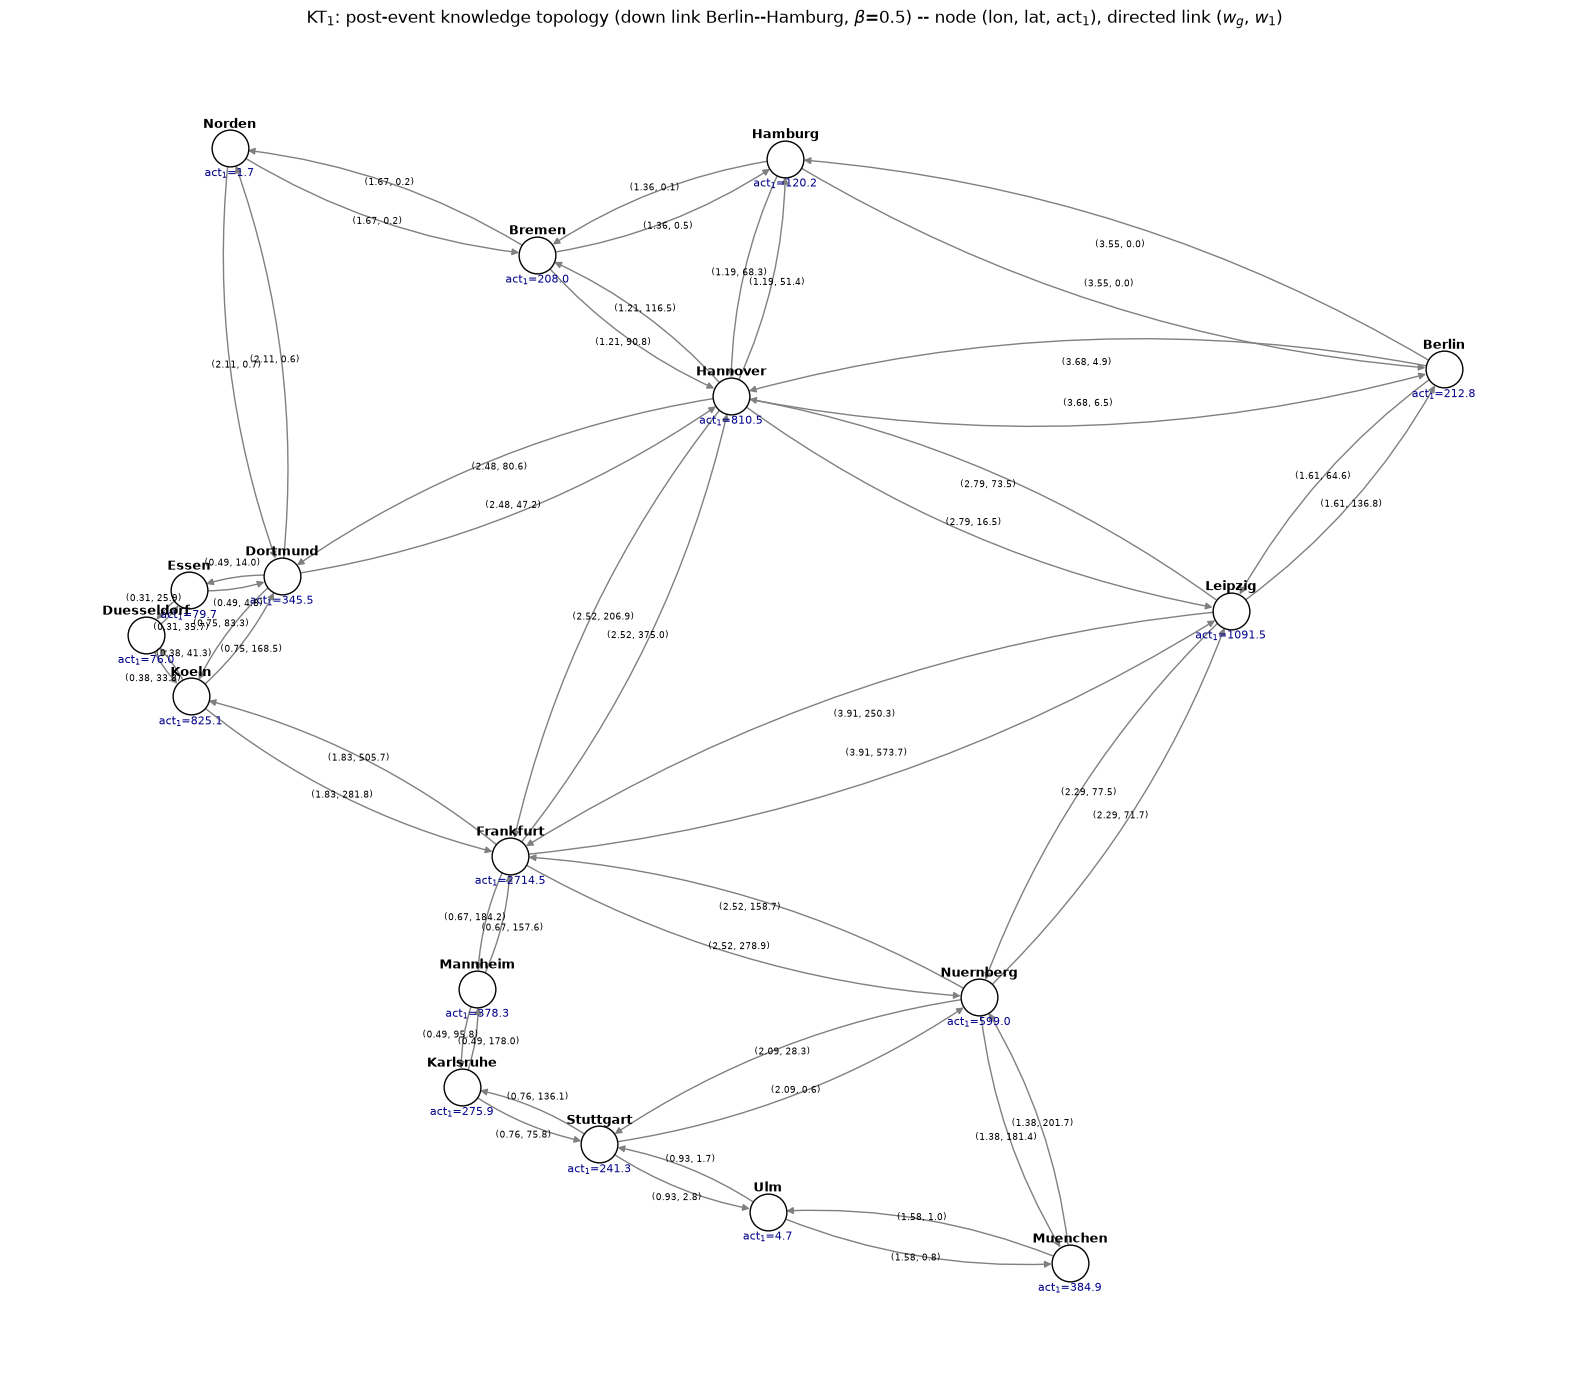

In [21]:
# ---- Plot KT1: same style as KT0 -- node (name, act1), directed edge labels (w_g, w_1) ----
fig, ax = plt.subplots(figsize=(16, 14))
pos = raw_nodes

KTG1 = nx.DiGraph()
KTG1.add_nodes_from(raw_nodes)
for (a, b) in links:
    KTG1.add_edge(a, b)
    KTG1.add_edge(b, a)

nx.draw_networkx_nodes(KTG1, pos, node_size=700, node_color="white", edgecolors="black", ax=ax)
nx.draw_networkx_edges(KTG1, pos, arrows=True, arrowsize=10, edge_color="grey",
                       connectionstyle="arc3,rad=0.12", ax=ax, node_size=700)

for n, (x, y) in pos.items():
    ax.text(x, y + 0.10, n, ha="center", fontsize=9, fontweight="bold")
    ax.text(x, y - 0.14, f"act$_1$={act1[n]:.1f}", ha="center", fontsize=8, color="darkblue")

for (a, b) in KTG1.edges():
    (x1, y1), (x2, y2) = pos[a], pos[b]
    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    dx, dy = x2 - x1, y2 - y1
    L = math.hypot(dx, dy)
    px, py = -dy / L, dx / L
    off = 0.10
    ax.text(mx + px * off, my + py * off, f"({w_g[(a, b)]:.2f}, {w1[(a, b)]:.1f})",
            ha="center", va="center", fontsize=6.5, color="black")

ax.set_title("KT$_1$: post-event knowledge topology (down link Berlin--Hamburg, $\\beta$=%.1f) -- "
             "node (lon, lat, act$_1$), directed link ($w_g$, $w_1$)" % beta)
ax.set_axis_off()
plt.tight_layout()
plt.show()


## KT0 vs KT1 comparison, and ground-truth ratio map

1. KT0 and KT1 side by side (small scale, same style).
2. Separate plot of the evaluation targets: node DF1(v) = act1(v)/act0(v), directed link rho(l) = w1(l)/w0(l).

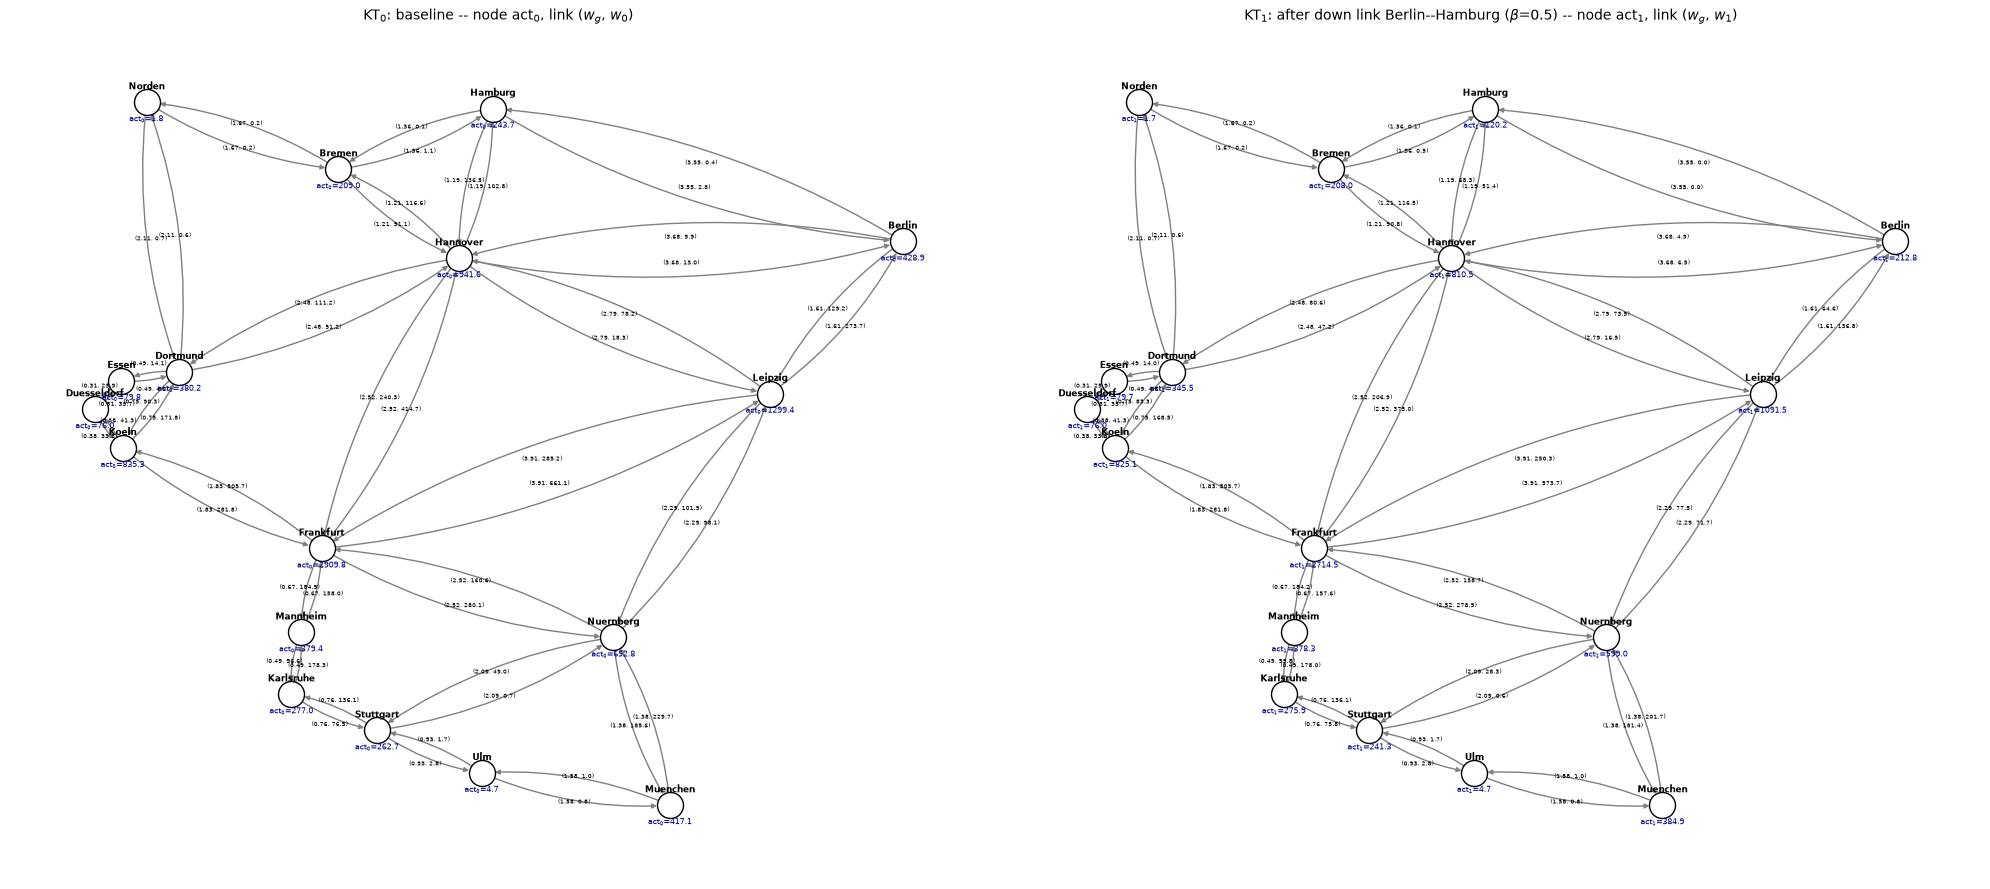

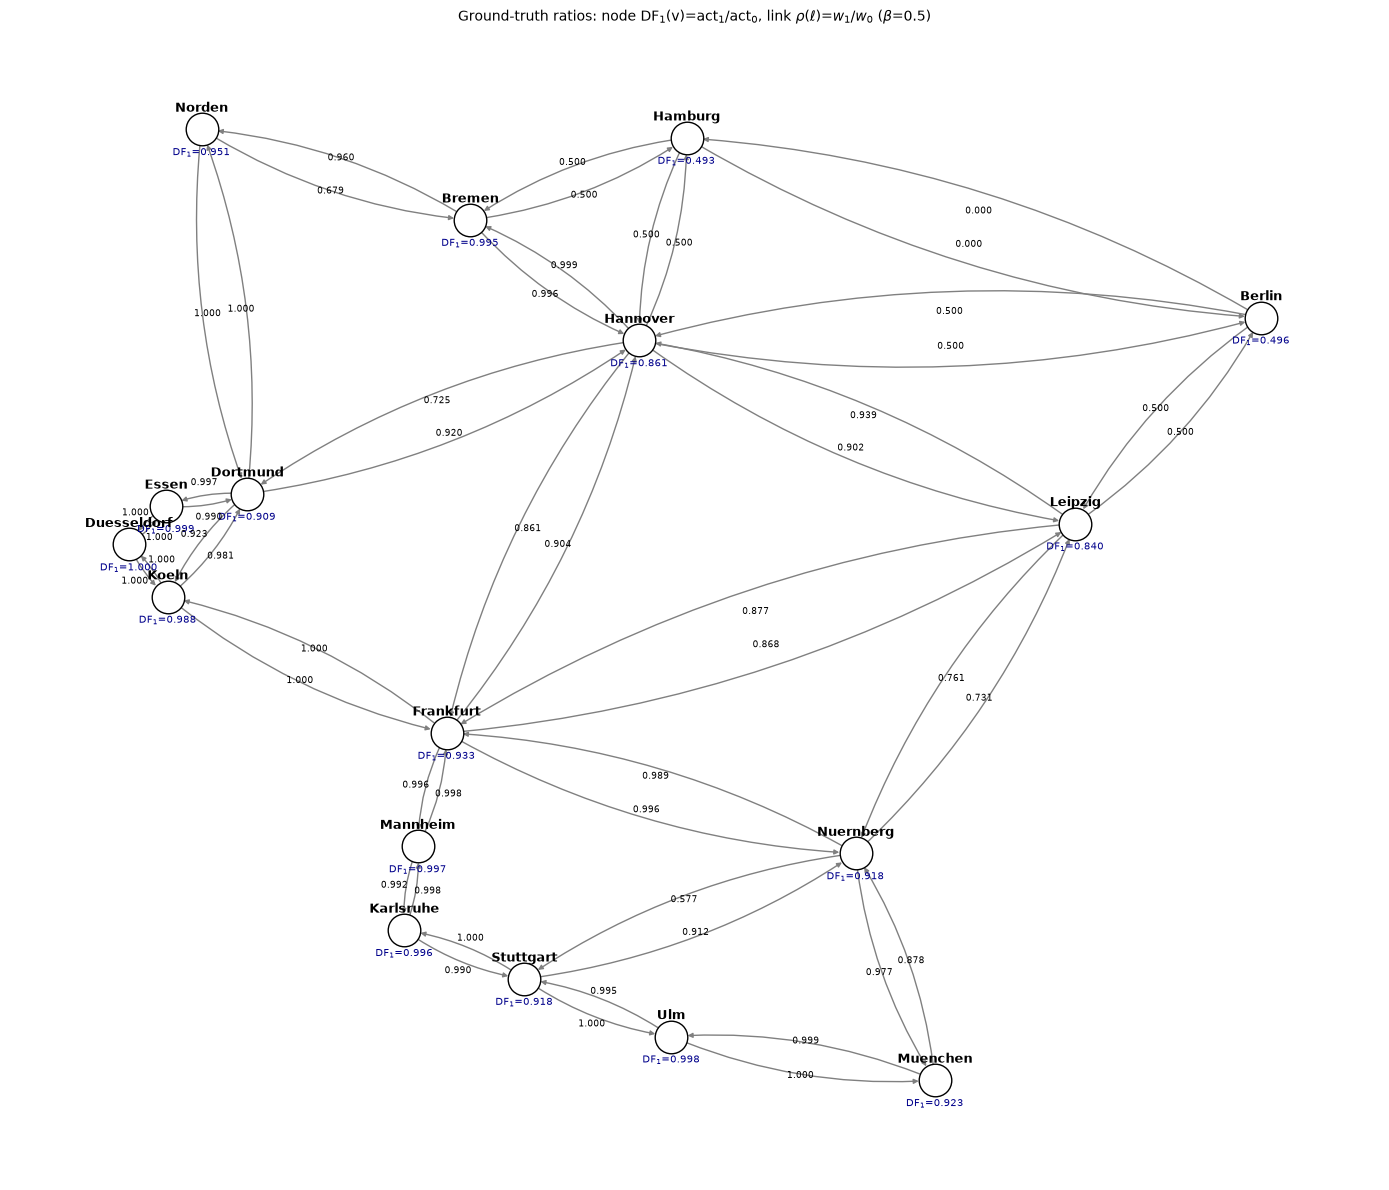

In [22]:
# ---- Shared drawing helper + comparison plots ----
def draw_kt(ax, node_label_fn, edge_label_fn, title,
            node_size=350, name_fs=6.5, val_fs=5.5, edge_fs=4.5):
    pos = raw_nodes
    KTG = nx.DiGraph()
    KTG.add_nodes_from(raw_nodes)
    for (a, b) in links:
        KTG.add_edge(a, b)
        KTG.add_edge(b, a)
    nx.draw_networkx_nodes(KTG, pos, node_size=node_size, node_color="white",
                           edgecolors="black", ax=ax)
    nx.draw_networkx_edges(KTG, pos, arrows=True, arrowsize=7, edge_color="grey",
                           connectionstyle="arc3,rad=0.12", ax=ax, node_size=node_size)
    for n, (x, y) in pos.items():
        ax.text(x, y + 0.10, n, ha="center", fontsize=name_fs, fontweight="bold")
        ax.text(x, y - 0.15, node_label_fn(n), ha="center", fontsize=val_fs, color="darkblue")
    for (a, b) in KTG.edges():
        (x1, y1), (x2, y2) = pos[a], pos[b]
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        dx, dy = x2 - x1, y2 - y1
        L = math.hypot(dx, dy)
        px, py = -dy / L, dx / L
        ax.text(mx + px * 0.10, my + py * 0.10, edge_label_fn((a, b)),
                ha="center", va="center", fontsize=edge_fs)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()

# 1+3. KT0 | KT1 as two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
draw_kt(axes[0], lambda n: f"act$_0$={act0[n]:.1f}",
        lambda l: f"({w_g[l]:.2f}, {w0[l]:.1f})",
        "KT$_0$: baseline -- node act$_0$, link ($w_g$, $w_0$)")
draw_kt(axes[1], lambda n: f"act$_1$={act1[n]:.1f}",
        lambda l: f"({w_g[l]:.2f}, {w1[l]:.1f})",
        f"KT$_1$: after down link Berlin--Hamburg ($\\beta$={beta}) -- node act$_1$, link ($w_g$, $w_1$)")
plt.tight_layout()
plt.show()

# 2+3. Ground-truth ratio map as a separate plot
fig2, ax2 = plt.subplots(figsize=(14, 12))
draw_kt(ax2, lambda n: f"DF$_1$={DF1[n]:.3f}",
        lambda l: f"{rho[l]:.3f}",
        f"Ground-truth ratios: node DF$_1$(v)=act$_1$/act$_0$, link $\\rho(\\ell)$=$w_1$/$w_0$ ($\\beta$={beta})",
        node_size=550, name_fs=9, val_fs=7.5, edge_fs=6.5)
plt.tight_layout()
plt.show()
